In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
import warnings
import math

from rich import print
warnings.filterwarnings("ignore")

print('[green]Importing Libraries Successfully... [green]')

Importing Libraries Successfully... 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv('WineQT.csv',index_col='Id')
print('[green]Data loaded Successfully...[green]')

Data loaded Successfully...

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
775,7.2,1.00,0.00,3.0,0.102,7.0,16.0,0.99586,3.43,0.46,10.0,5
1499,6.9,0.74,0.03,2.3,0.054,7.0,16.0,0.99508,3.45,0.63,11.5,6
559,13.0,0.47,0.49,4.3,0.085,6.0,47.0,1.00210,3.30,0.68,12.7,6
354,6.1,0.21,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9,6
168,6.8,0.63,0.07,2.1,0.089,11.0,44.0,0.99530,3.47,0.55,10.4,6


In [ ]:
print('The number of rows:',df.shape[0])
print('The number of columns:',df.shape[1])

The number of rows: 1143

The number of columns: 12

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
df.shape

(1143, 12)

In [ ]:
df.size

13716

In [ ]:
df.nunique()

,0
fixed acidity,91
volatile acidity,135
citric acid,77
residual sugar,80
chlorides,131
free sulfur dioxide,53
total sulfur dioxide,138
density,388
pH,87
sulphates,89


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1143 entries, 0 to 1597
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 116.1 KB


In [ ]:
df.describe(include='all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df.describe().T.round(2).style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.000000,8.310000,1.750000,4.600000,7.100000,7.900000,9.100000,15.900000
volatile acidity,1143.000000,0.530000,0.180000,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1143.000000,0.270000,0.200000,0.000000,0.090000,0.250000,0.420000,1.000000
residual sugar,1143.000000,2.530000,1.360000,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1143.000000,0.090000,0.050000,0.010000,0.070000,0.080000,0.090000,0.610000
free sulfur dioxide,1143.000000,15.620000,10.250000,1.000000,7.000000,13.000000,21.000000,68.000000
total sulfur dioxide,1143.000000,45.910000,32.780000,6.000000,21.000000,37.000000,61.000000,289.000000
density,1143.000000,1.000000,0.000000,0.990000,1.000000,1.000000,1.000000,1.000000
pH,1143.000000,3.310000,0.160000,2.740000,3.200000,3.310000,3.400000,4.010000
sulphates,1143.000000,0.660000,0.170000,0.330000,0.550000,0.620000,0.730000,2.000000


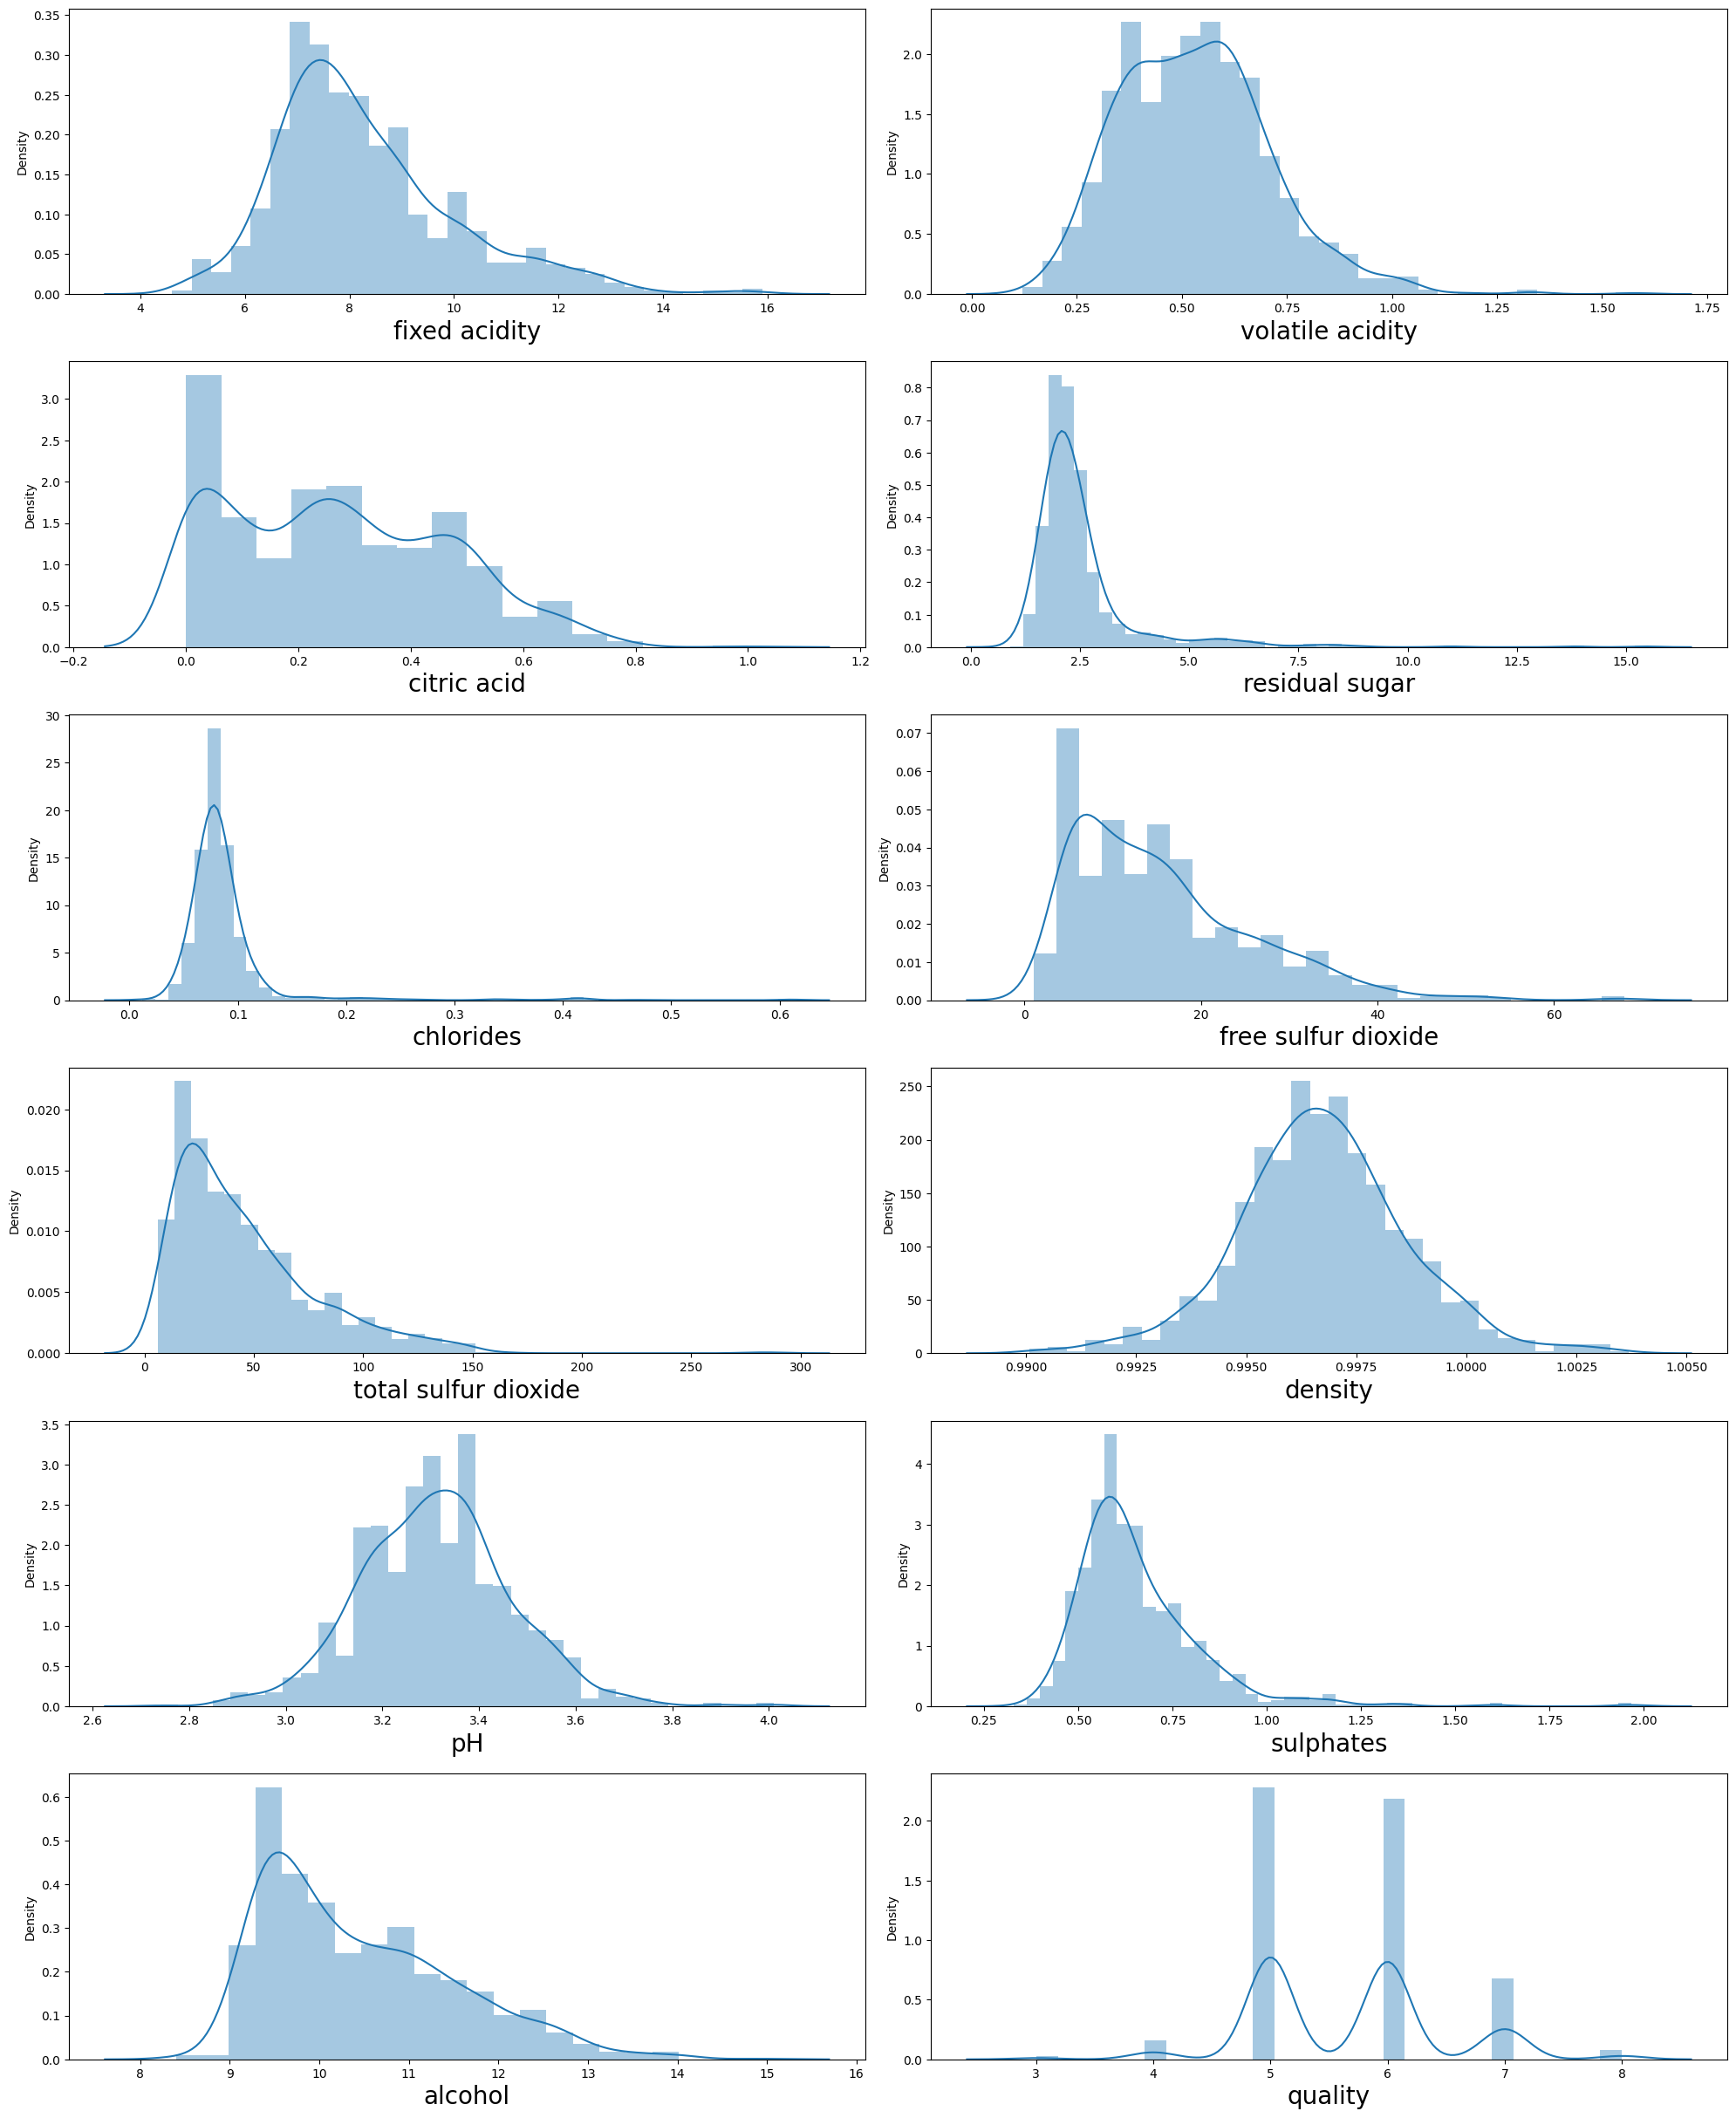

In [ ]:
plt.figure(figsize=(20,40))
plotnum = 1
for columns in df:
  if plotnum <= len(df.columns):
    ax = plt.subplot(10,2,plotnum)
    sns.distplot(df[columns])
    plt.xlabel(columns,fontsize=20)
    plotnum += 1
plt.tight_layout()
plt.show()

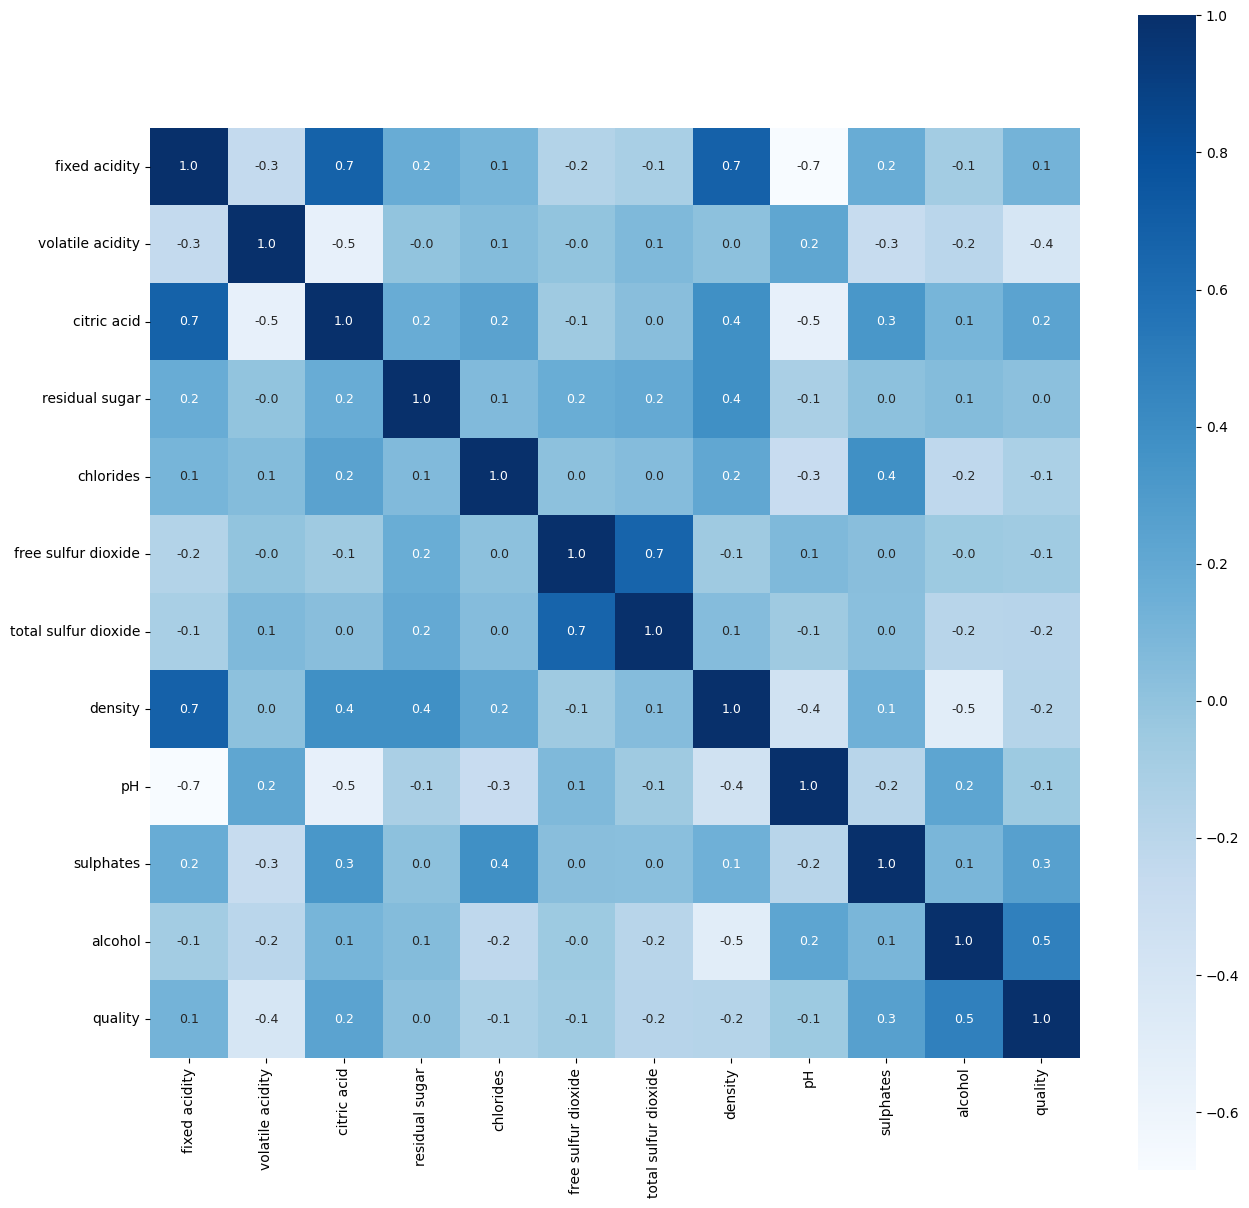

In [ ]:
corr = df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr,fmt='.1f',annot=True,cmap='Blues',cbar = True,square=True,annot_kws={'size':9})
plt.show()

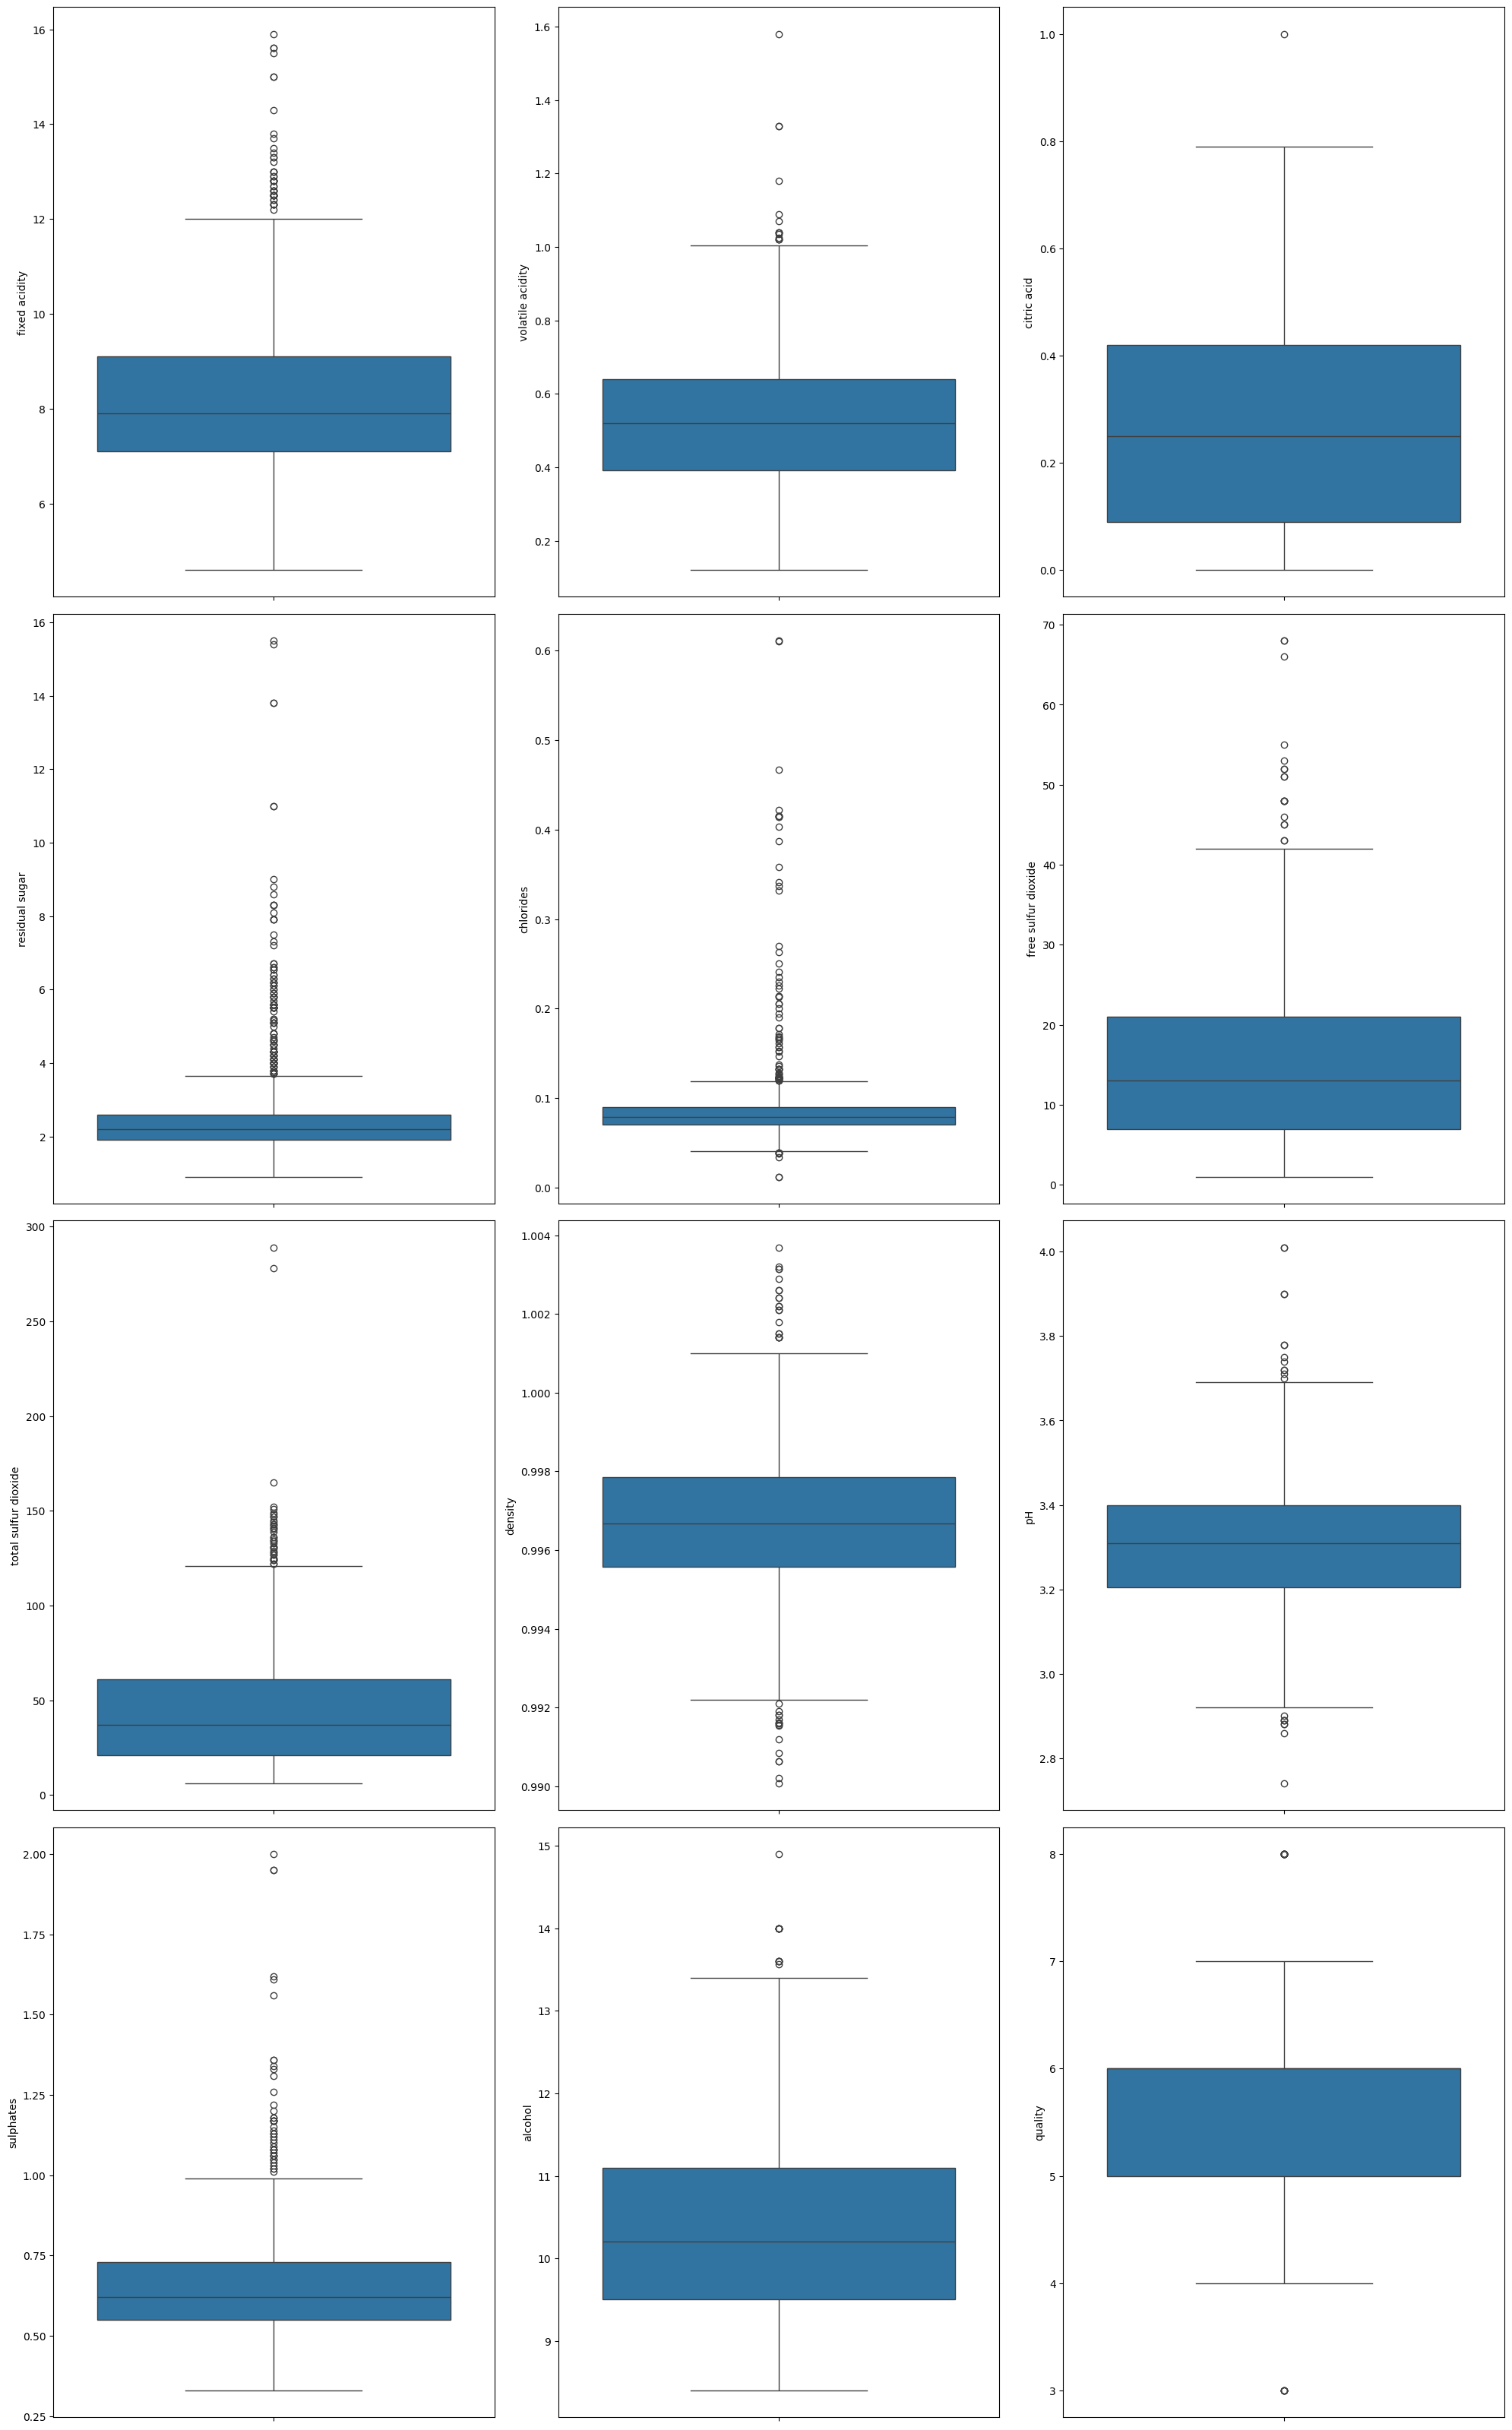

In [ ]:
plt.figure(figsize=(20,40))
plotnum = 1
for columns in df:
  if plotnum <= len(df.columns):
    ax = plt.subplot(5,3,plotnum)
    sns.boxplot(y=df[columns])
    plotnum += 1
plt.tight_layout()
plt.show()

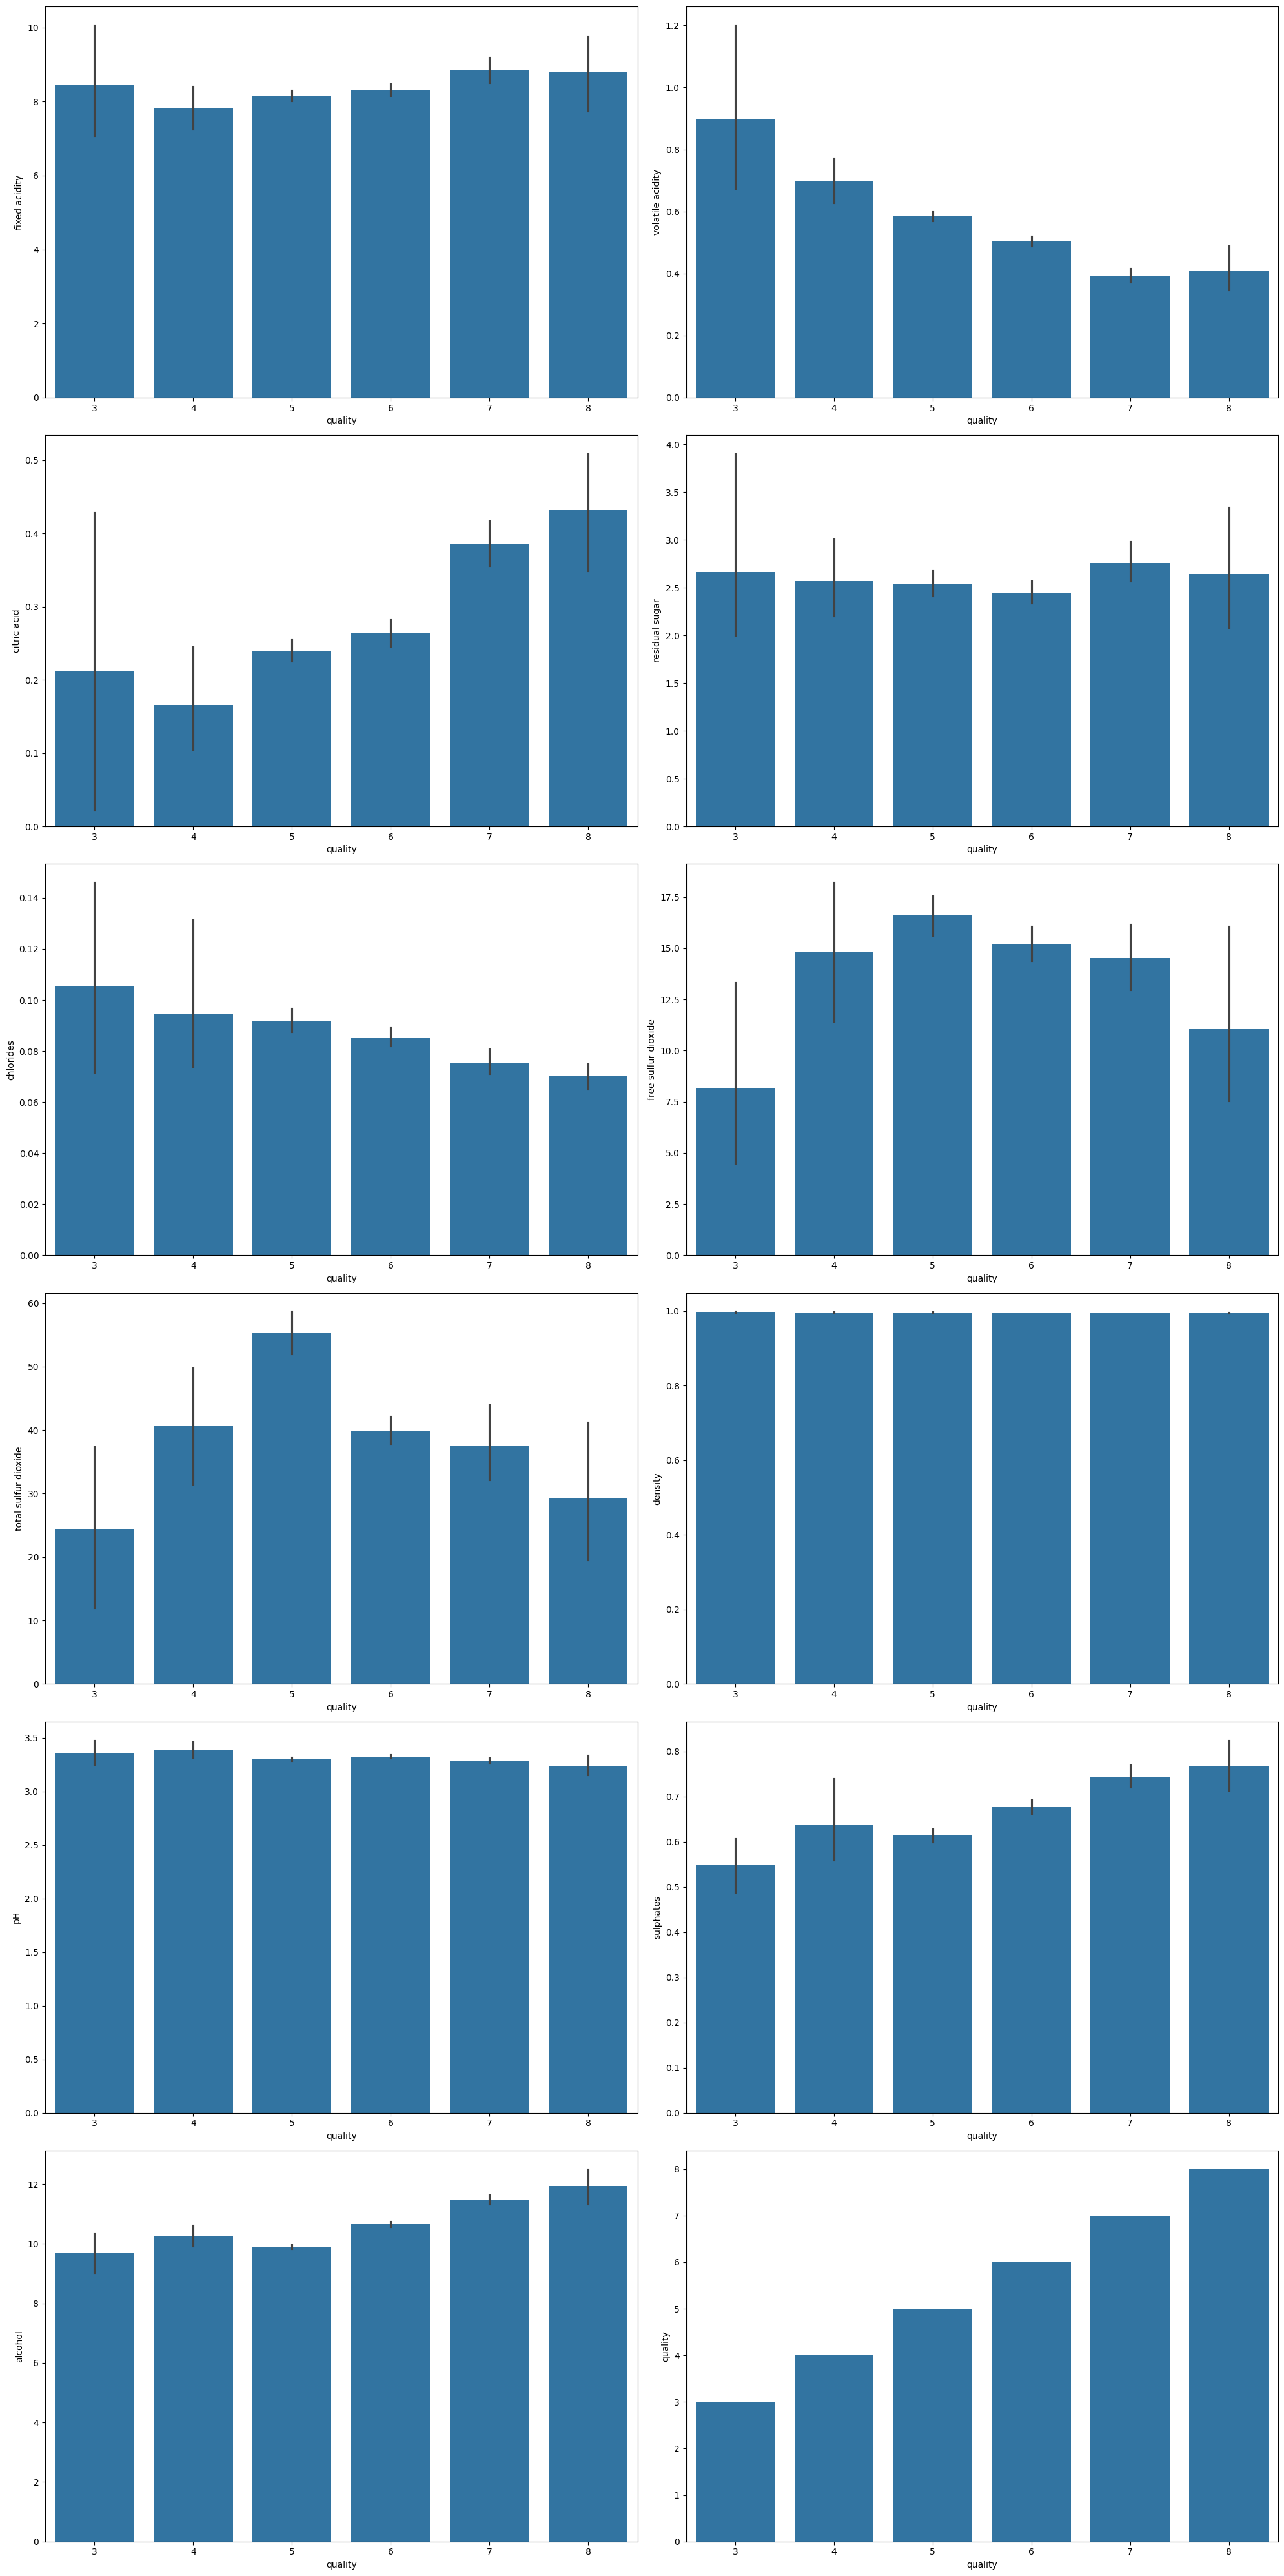

In [ ]:
plt.figure(figsize=(20,40))
plotnum = 1
for columns in df:
  if plotnum <= len(df.columns):
    ax = plt.subplot(6,2,plotnum)
    sns.barplot(x='quality',y=df[columns],data=df)
    plotnum += 1
plt.tight_layout()
plt.show()

In [ ]:
print('\n Value counts for quality :')
print(df['quality'].value_counts().sort_values(ascending=False))

Value counts for quality :

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

<Axes: xlabel='quality', ylabel='count'>

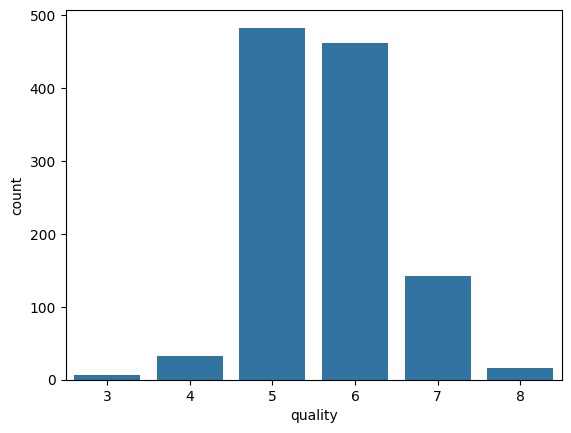

In [ ]:
sns.countplot(x=df['quality'],data=df)

In [ ]:
print(df.skew())

fixed acidity           1.044930
volatile acidity        0.681547
citric acid             0.371561
residual sugar          4.361096
chlorides               6.026360
free sulfur dioxide     1.231261
total sulfur dioxide    1.665766
density                 0.102395
pH                      0.221138
sulphates               2.497266
alcohol                 0.863313
quality                 0.286792
dtype: float64

In [ ]:
print(df.kurt())

fixed acidity            1.384614
volatile acidity         1.375531
citric acid             -0.714686
residual sugar          27.675366
chlorides               47.078324
free sulfur dioxide      1.932170
total sulfur dioxide     5.098748
density                  0.888123
pH                       0.925791
sulphates               12.017377
alcohol                  0.221179
quality                  0.314664
dtype: float64

## Statistical Hypothesis Testing

Before trusting the correlations above, test whether they are statistically significant (not just noise from a finite sample).

In [ ]:
from scipy import stats

# H0: no linear relationship between the feature and quality (r = 0)
for col in ['alcohol', 'volatile acidity', 'citric acid', 'sulphates']:
    r, p = stats.pearsonr(df[col], df['quality'])
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f'{col:20s} r = {r:6.3f}   p = {p:.2e}   -> {sig}')

**Good vs. poor wines — Welch's t-test on alcohol content**

H0: mean alcohol content is the same for high-quality (score ≥ 7) and low-quality (score ≤ 5) wines.

In [ ]:
good = df[df['quality'] >= 7]['alcohol']
poor = df[df['quality'] <= 5]['alcohol']

t_stat, p_val = stats.ttest_ind(good, poor, equal_var=False)

print(f'Mean alcohol - good wines (>=7): {good.mean():.2f}%')
print(f'Mean alcohol - poor wines (<=5): {poor.mean():.2f}%')
print(f't-statistic = {t_stat:.2f}, p-value = {p_val:.2e}')
print('Reject H0 -> good wines have significantly higher alcohol content.' if p_val < 0.05 else 'Fail to reject H0.')

**Volatile acidity across all quality levels — one-way ANOVA**

H0: mean volatile acidity is equal across every quality score group (3 through 8).

In [ ]:
groups = [g['volatile acidity'].values for _, g in df.groupby('quality')]
f_stat, p_val = stats.f_oneway(*groups)

print(f'F-statistic = {f_stat:.2f}, p-value = {p_val:.2e}')
print('Reject H0 -> volatile acidity differs significantly across quality levels.' if p_val < 0.05 else 'Fail to reject H0.')

## Outlier Detection (IQR Method)

Flag values beyond 1.5×IQR from the quartiles for every feature, to decide what needs winsorizing/transforming before modeling.

In [ ]:
outlier_summary = []
for col in df.columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'outliers': n_outliers, 'pct': round(n_outliers / len(df) * 100, 1)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('pct', ascending=False)
outlier_df

## Quality Class Imbalance

`quality` is the modeling target — check how imbalanced it is, since this affects both evaluation metrics and the SMOTE resampling used later in this notebook.

In [ ]:
quality_pct = (df['quality'].value_counts(normalize=True).sort_index() * 100).round(1)
print('Quality score distribution (%):')
print(quality_pct)

plt.figure(figsize=(7,4))
sns.barplot(x=quality_pct.index, y=quality_pct.values, color='#7a3b5e')
plt.ylabel('% of samples')
plt.xlabel('quality')
plt.title('Quality score distribution — scores 5 & 6 dominate the dataset')
plt.show()

In [ ]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
print('Number of Null in DataFrame is: ',df.isnull().sum().sum())

Number of Null in DataFrame is:  0

In [ ]:
print('Number of NaN in DataFrame is: ',df.isna().sum().sum())

Number of NaN in DataFrame is:  0

In [ ]:
print('Number of duplicate in DataFrame is: ',df.duplicated().sum().sum())

Number of duplicate in DataFrame is:  125

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print('Number of Null in DataFrame is: ',df.isnull().sum().sum())
print('Number of NaN in DataFrame is: ',df.isna().sum().sum())
print('Number of duplicate in DataFrame is: ',df.duplicated().sum().sum())

Number of Null in DataFrame is:  0

Number of NaN in DataFrame is:  0

Number of duplicate in DataFrame is:  0

In [ ]:
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values
print('[green]Separating Successfully...[green]')

Separating Successfully...

**Data Sampling**

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
X_resampled,Y_resampled = smote.fit_resample(x,y)
print("Resampled Class Distribution:",Counter(Y_resampled))

Resampled Class Distribution:
Counter({
    np.int64(5): 433,
    np.int64(6): 433,
    np.int64(7): 433,
    np.int64(4): 433,
    np.int64(8): 433,
    np.int64(3): 433
})

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_resampled = scaler.fit_transform(X_resampled)

In [ ]:
X_resampled.std()

np.float64(1.090002553146717)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_resampled,Y_resampled,test_size=0.2,random_state=11)

In [ ]:
print('X Shape:',x.shape)
print('Y Shape:',y.shape)

print('X_train shape:',x_train.shape)
print('Y_train shape:',y_train.shape)

print('X_test shape:',x_test.shape)
print('Y_test shape:',y_test.shape)

X Shape:
(1018, 11)

Y Shape:
(1018,)

X_train shape:
(2078, 11)

Y_train shape:
(2078,)

X_test shape:
(520, 11)

Y_test shape:
(520,)

In [ ]:
results = []
def training_models(model_name,model):
  model.fit(x_train,y_train)

  x_train_pred = model.predict(x_train)
  x_test_pred = model.predict(x_test)

  accuracy_train = accuracy_score(y_train,x_train_pred)
  accuracy_test = accuracy_score(y_test,x_test_pred)

  report = classification_report(y_test,x_test_pred)

  print(f"[bold cyan]The Accuracy Score of training by {model_name}(Train):[/bold cyan] {accuracy_train:.2f}")
  print(f"[bold magenta]The Accuracy Score of Training by {model_name}(Test):[/bold magenta] {accuracy_test:.2f}\n")

  print('[bold yellow]Classification Report:[/bold yellow]')
  print(report)

  print('[bold green]Training Complete...[/bold green]')

  results.append({
      "Model":model_name,
      "Accuracy_Test":accuracy_test
  })

In [ ]:
from sklearn.linear_model import LogisticRegression
logs = LogisticRegression()
training_models('Logistic Regression',logs)

The Accuracy Score of training by Logistic Regression(Train): 0.64

The Accuracy Score of Training by Logistic Regression(Test): 0.63

Classification Report:

precision    recall  f1-score   support

           3       0.86      0.96      0.91        85
           4       0.65      0.56      0.60        94
           5       0.52      0.58      0.55        79
           6       0.46      0.39      0.43        84
           7       0.54      0.51      0.52        89
           8       0.69      0.76      0.72        89

    accuracy                           0.63       520
   macro avg       0.62      0.63      0.62       520
weighted avg       0.62      0.63      0.62       520

Training Complete...

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
training_models('Decision Tree Classifier',dtc)

The Accuracy Score of training by Decision Tree Classifier(Train): 1.00

The Accuracy Score of Training by Decision Tree Classifier(Test): 0.75

Classification Report:

precision    recall  f1-score   support

           3       0.98      0.96      0.97        85
           4       0.82      0.85      0.83        94
           5       0.50      0.53      0.52        79
           6       0.47      0.38      0.42        84
           7       0.76      0.83      0.80        89
           8       0.92      0.92      0.92        89

    accuracy                           0.75       520
   macro avg       0.74      0.75      0.74       520
weighted avg       0.75      0.75      0.75       520

Training Complete...

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
training_models('Random Forest Classifier',rfc)

The Accuracy Score of training by Random Forest Classifier(Train): 1.00

The Accuracy Score of Training by Random Forest Classifier(Test): 0.83

Classification Report:

precision    recall  f1-score   support

           3       0.99      1.00      0.99        85
           4       0.87      0.93      0.90        94
           5       0.68      0.68      0.68        79
           6       0.58      0.45      0.51        84
           7       0.81      0.90      0.85        89
           8       0.96      0.97      0.96        89

    accuracy                           0.83       520
   macro avg       0.81      0.82      0.82       520
weighted avg       0.82      0.83      0.82       520

Training Complete...

In [ ]:
from sklearn.svm import SVC
svc = SVC()
training_models('Support Vector Classifier',svc)

The Accuracy Score of training by Support Vector Classifier(Train): 0.78

The Accuracy Score of Training by Support Vector Classifier(Test): 0.72

Classification Report:

precision    recall  f1-score   support

           3       0.87      1.00      0.93        85
           4       0.80      0.77      0.78        94
           5       0.55      0.56      0.55        79
           6       0.46      0.39      0.42        84
           7       0.73      0.69      0.71        89
           8       0.81      0.89      0.85        89

    accuracy                           0.72       520
   macro avg       0.70      0.71      0.71       520
weighted avg       0.71      0.72      0.71       520

Training Complete...

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
training_models('Gaussian Naive Bayes',gnb)

The Accuracy Score of training by Gaussian Naive Bayes(Train): 0.55

The Accuracy Score of Training by Gaussian Naive Bayes(Test): 0.53

Classification Report:

precision    recall  f1-score   support

           3       0.58      1.00      0.74        85
           4       0.50      0.37      0.43        94
           5       0.51      0.38      0.43        79
           6       0.36      0.24      0.29        84
           7       0.48      0.34      0.40        89
           8       0.59      0.85      0.70        89

    accuracy                           0.53       520
   macro avg       0.51      0.53      0.50       520
weighted avg       0.51      0.53      0.50       520

Training Complete...

In [ ]:
result_df = pd.DataFrame(results)
print(result_df.sort_values(by = "Accuracy_Test",ascending = False))

Model  Accuracy_Test
2   Random Forest Classifier       0.826923
1   Decision Tree Classifier       0.753846
3  Support Vector Classifier       0.719231
0        Logistic Regression       0.628846
4       Gaussian Naive Bayes       0.530769

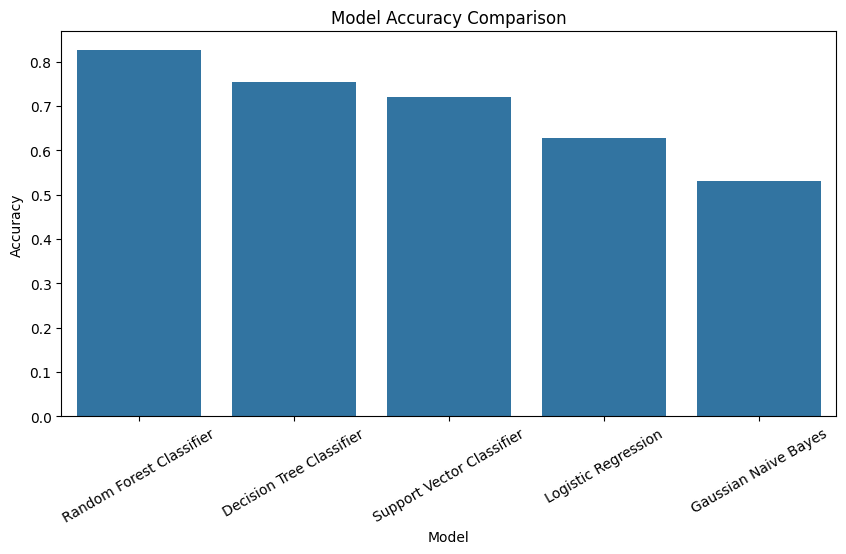

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Model',y='Accuracy_Test',data=result_df.sort_values(by='Accuracy_Test',ascending=False))
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation = 30)
plt.show()

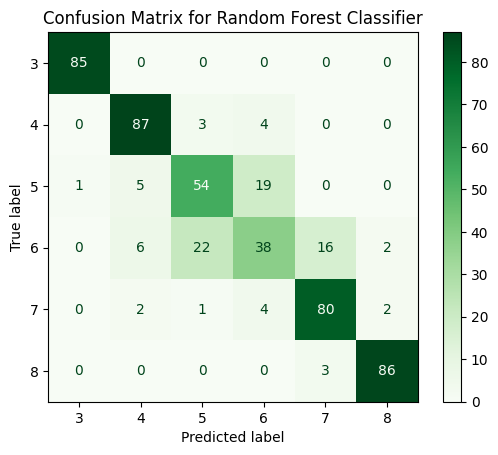

In [ ]:
best_model_name = result_df.sort_values(by='Accuracy_Test',ascending=False).iloc[0]['Model']

model_dict = {
    'Logistic Regression': logs,
    'Decision Tree Classifier': dtc,
    'Random Forest Classifier': rfc,
    'Support Vector Classifier': svc,
    'Gaussian Naive Bayes': gnb
}

best_model = model_dict[best_model_name]

y_pred = best_model.predict(x_test)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Greens',values_format='d')
plt.title(f"Confusion Matrix for {best_model_name}")
plt.show()

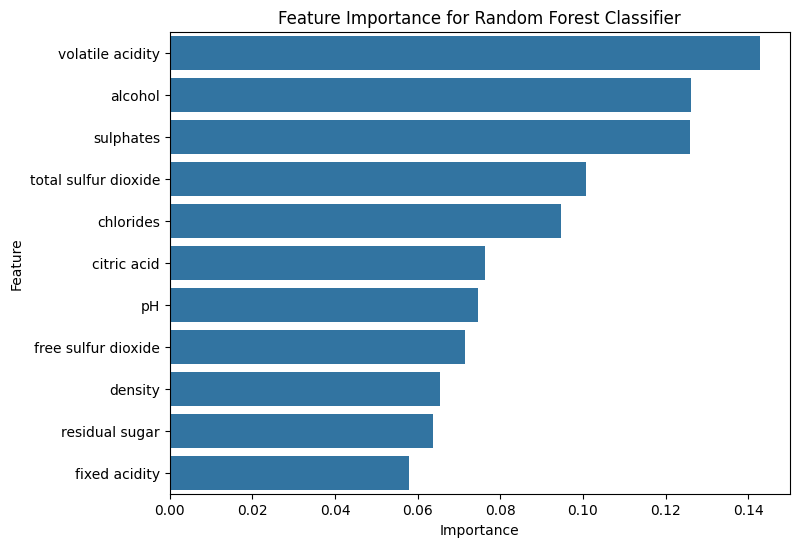

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': df.columns[:-1],
        'Importance': best_model.feature_importances_
    }).sort_values(by = 'Importance', ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(x='Importance', y='Feature', data=importances)
    plt.title(f"Feature Importance for {best_model_name}")
    plt.show()
else:
    print(f"{best_model_name} does not provide feature importance.")

In [ ]:
new_wine = np.array([[7.4,0.7,0.0,1.9,0.076,
                      11.0,34.0,0.9978,3.51,0.56,9.4]])

new_wine_scaled = scaler.transform(new_wine)

predicted_quality = best_model.predict(new_wine_scaled)

print(f"Predicted Wine Quality: {predicted_quality[0]}")

Predicted Wine Quality: 5

In [ ]:
import joblib
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

best_model = RandomForestClassifier()
best_model.fit(x_train_scaled, y_train)

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'wine_scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!

In [ ]:
model = joblib.load('best_model.pkl')
scaler = joblib.load('wine_scaler.pkl')

features = np.array([[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]])
features_scaled = scaler.transform(features)
prediction = model.predict(features_scaled)
print("Predicted wine quality:",int(prediction[0]))

Predicted wine quality: 6